## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import (mean_absolute_error, mean_squared_error,
                                      r2_score, mean_absolute_percentage_error)
from sklearn.decomposition   import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries loaded successfully.')
print(f'numpy {np.__version__}  |  pandas {pd.__version__}  |  matplotlib {matplotlib.__version__}')

All libraries loaded successfully.
numpy 2.4.4  |  pandas 3.0.3  |  matplotlib 3.10.9


## Load Data

In [4]:
df = pd.read_csv('hour.csv')

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: 17,379 rows x 17 columns
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
print('Statistical Summary:')
df.describe().T.round(3)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000,5017.029,1.00,4345.500,8690.000,13034.500,17379.000
season,17379.0,2.502,1.107,1.00,2.000,3.000,3.000,4.000
yr,17379.0,0.503,0.500,0.00,0.000,1.000,1.000,1.000
mnth,17379.0,6.538,3.439,1.00,4.000,7.000,10.000,12.000
hr,17379.0,11.547,6.914,0.00,6.000,12.000,18.000,23.000
holiday,17379.0,0.029,0.167,0.00,0.000,0.000,0.000,1.000
weekday,17379.0,3.004,2.006,0.00,1.000,3.000,5.000,6.000
workingday,17379.0,0.683,0.465,0.00,0.000,1.000,1.000,1.000
weathersit,17379.0,1.425,0.639,1.00,1.000,1.000,2.000,4.000
temp,17379.0,0.497,0.193,0.02,0.340,0.500,0.660,1.000


## Data Preprocessing


In [6]:
df.drop(columns=['instant', 'dteday'], inplace=True)

# casual + registered sum exactly to cnt  ->  direct data leakage
df.drop(columns=['casual', 'registered'], inplace=True)

print('Dropped: instant, dteday  (identifiers — no predictive signal)')
print('Dropped: casual, registered  (data leakage — they arithmetically equal the target)')
print(f'\nShape after drop: {df.shape}')
print(f'Remaining columns: {list(df.columns)}')

Dropped: instant, dteday  (identifiers — no predictive signal)
Dropped: casual, registered  (data leakage — they arithmetically equal the target)

Shape after drop: (17379, 13)
Remaining columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


### Missing Value Analysis

In [7]:
print('MISSING VALUE AUDIT')
print('=' * 40)
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
mv_df       = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})

if mv_df['Null Count'].sum() == 0:
    print('No missing values detected in any column.')
else:
    print(mv_df[mv_df['Null Count'] > 0])

print(f'\nTotal missing cells: {null_counts.sum()}')
print('\nResult: Dataset is complete. No imputation required.')

MISSING VALUE AUDIT
No missing values detected in any column.

Total missing cells: 0

Result: Dataset is complete. No imputation required.


### Invalid Value Check

In [8]:
print('INVALID VALUE CHECK')
print('=' * 40)
cont_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
for col in cont_cols:
    n_neg = (df[col] < 0).sum()
    status = 'OK — no negative values' if n_neg == 0 else f'WARNING: {n_neg} negative values'
    print(f'  {col:12s}: {status}')

zero_hum = (df['hum'] == 0).sum()
if zero_hum > 0:
    med_hum = df['hum'].median()
    df.loc[df['hum'] == 0, 'hum'] = med_hum
    print(f'\n  hum = 0 found: {zero_hum} records replaced with median ({med_hum:.4f})')
else:
    print('\n  hum = 0: none found — no imputation required')

INVALID VALUE CHECK
  temp        : OK — no negative values
  atemp       : OK — no negative values
  hum         : OK — no negative values
  windspeed   : OK — no negative values
  cnt         : OK — no negative values

  hum = 0 found: 22 records replaced with median (0.6300)


### Outlier Detection & Capping (IQR Method)

In [9]:
print('OUTLIER DETECTION & CAPPING — IQR METHOD')
print('=' * 52)

cap_cols = ['hum', 'windspeed']
for col in cap_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'  {col:12s} | {n_out:4d} outliers capped | bounds [{lower:.4f}, {upper:.4f}]')

Q1_c  = df['cnt'].quantile(0.25)
Q3_c  = df['cnt'].quantile(0.75)
IQR_c = Q3_c - Q1_c
n_cnt = ((df['cnt'] < Q1_c - 1.5*IQR_c) | (df['cnt'] > Q3_c + 1.5*IQR_c)).sum()
print(f'  cnt (target) | {n_cnt:4d} statistical outliers | NOT capped')
print('  Rationale: high-demand hours are genuine peaks the model must learn to predict.')

df_eda = df.copy()

OUTLIER DETECTION & CAPPING — IQR METHOD
  hum          |    0 outliers capped | bounds [0.0300, 1.2300]
  windspeed    |  342 outliers capped | bounds [-0.1193, 0.4775]
  cnt (target) |  505 statistical outliers | NOT capped
  Rationale: high-demand hours are genuine peaks the model must learn to predict.


### One-Hot Encoding

In [10]:
df = pd.get_dummies(df, columns=['season', 'weathersit'], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('ONE-HOT ENCODING COMPLETE')
print('=' * 52)
print('  season     -> season_2, season_3, season_4     (Spring = reference, dropped)')
print('  weathersit -> weathersit_2, weathersit_3, weathersit_4  (Clear = reference)')
print(f'\nFinal preprocessed shape: {df.shape}')
print(f'All columns: {list(df.columns)}')

ONE-HOT ENCODING COMPLETE
  season     -> season_2, season_3, season_4     (Spring = reference, dropped)
  weathersit -> weathersit_2, weathersit_3, weathersit_4  (Clear = reference)

Final preprocessed shape: (17379, 17)
All columns: ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4']


## Train / Test Split (80 / 20)

In [11]:
X = df.drop(columns=['cnt'])
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print('TRAIN / TEST SPLIT  (80 / 20)')
print('=' * 45)
print(f'  Full dataset : {len(X):,} samples')
print(f'  Training set : {len(X_train):,} samples  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Test set     : {len(X_test):,} samples  ({len(X_test)/len(X)*100:.1f}%)')
n_feat = X_train.shape[1]
t_mean = round(y_train.mean(), 2)
t_std  = round(y_train.std(),  2)
v_mean = round(y_test.mean(),  2)
v_std  = round(y_test.std(),   2)
print(f'\n  Train target: mean={t_mean}, std={t_std}, range=[{y_train.min()}, {y_train.max()}]')
print(f'  Test  target: mean={v_mean}, std={v_std}, range=[{y_test.min()}, {y_test.max()}]')
print(f'\n  Features: {n_feat}    random_state=42')

TRAIN / TEST SPLIT  (80 / 20)
  Full dataset : 17,379 samples
  Training set : 13,903 samples  (80.0%)
  Test set     : 3,476 samples  (20.0%)

  Train target: mean=190.58, std=182.22, range=[1, 976]
  Test  target: mean=185.01, std=177.97, range=[1, 977]

  Features: 16    random_state=42


## Scale the Data

In [12]:
feature_names = list(X_train.columns)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('STANDARD SCALING APPLIED')
print('=' * 45)
print('  Scaler  : StandardScaler (mean=0, unit variance)')
print('  Fit on  : Training set ONLY — no test leakage')
print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')

STANDARD SCALING APPLIED
  Scaler  : StandardScaler (mean=0, unit variance)
  Fit on  : Training set ONLY — no test leakage
  X_train_scaled : (13903, 16)
  X_test_scaled  : (3476, 16)


## Exploratory Data Analysis (EDA)


### Target Variable Distribution

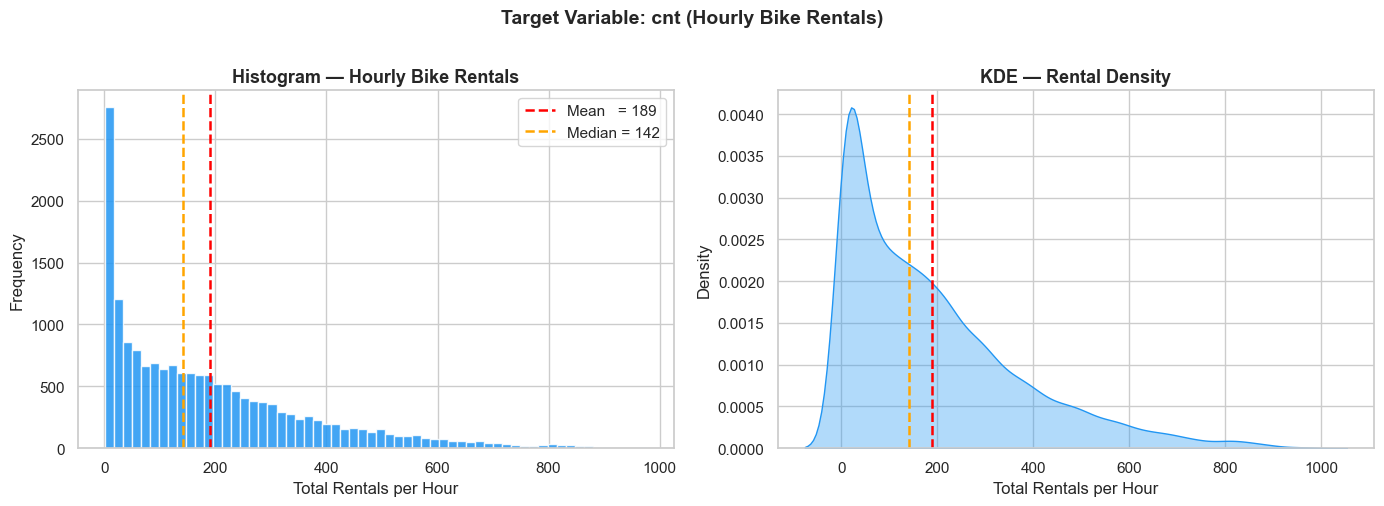

Skewness : 1.277  (>0 = right-skewed)
Kurtosis : 1.417


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(y.mean(),   color='red',    linestyle='--', lw=1.8, label=f'Mean   = {y.mean():.0f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', lw=1.8, label=f'Median = {y.median():.0f}')
axes[0].set_title('Histogram — Hourly Bike Rentals', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Rentals per Hour')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.kdeplot(y, ax=axes[1], color='#2196F3', fill=True, alpha=0.35)
axes[1].axvline(y.mean(),   color='red',    linestyle='--', lw=1.8)
axes[1].axvline(y.median(), color='orange', linestyle='--', lw=1.8)
axes[1].set_title('KDE — Rental Density', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Rentals per Hour')
axes[1].set_ylabel('Density')

plt.suptitle('Target Variable: cnt (Hourly Bike Rentals)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

skew_val = round(y.skew(), 3)
kurt_val = round(y.kurtosis(), 3)
print(f'Skewness : {skew_val}  (>0 = right-skewed)')
print(f'Kurtosis : {kurt_val}')

### Correlation Heatmap

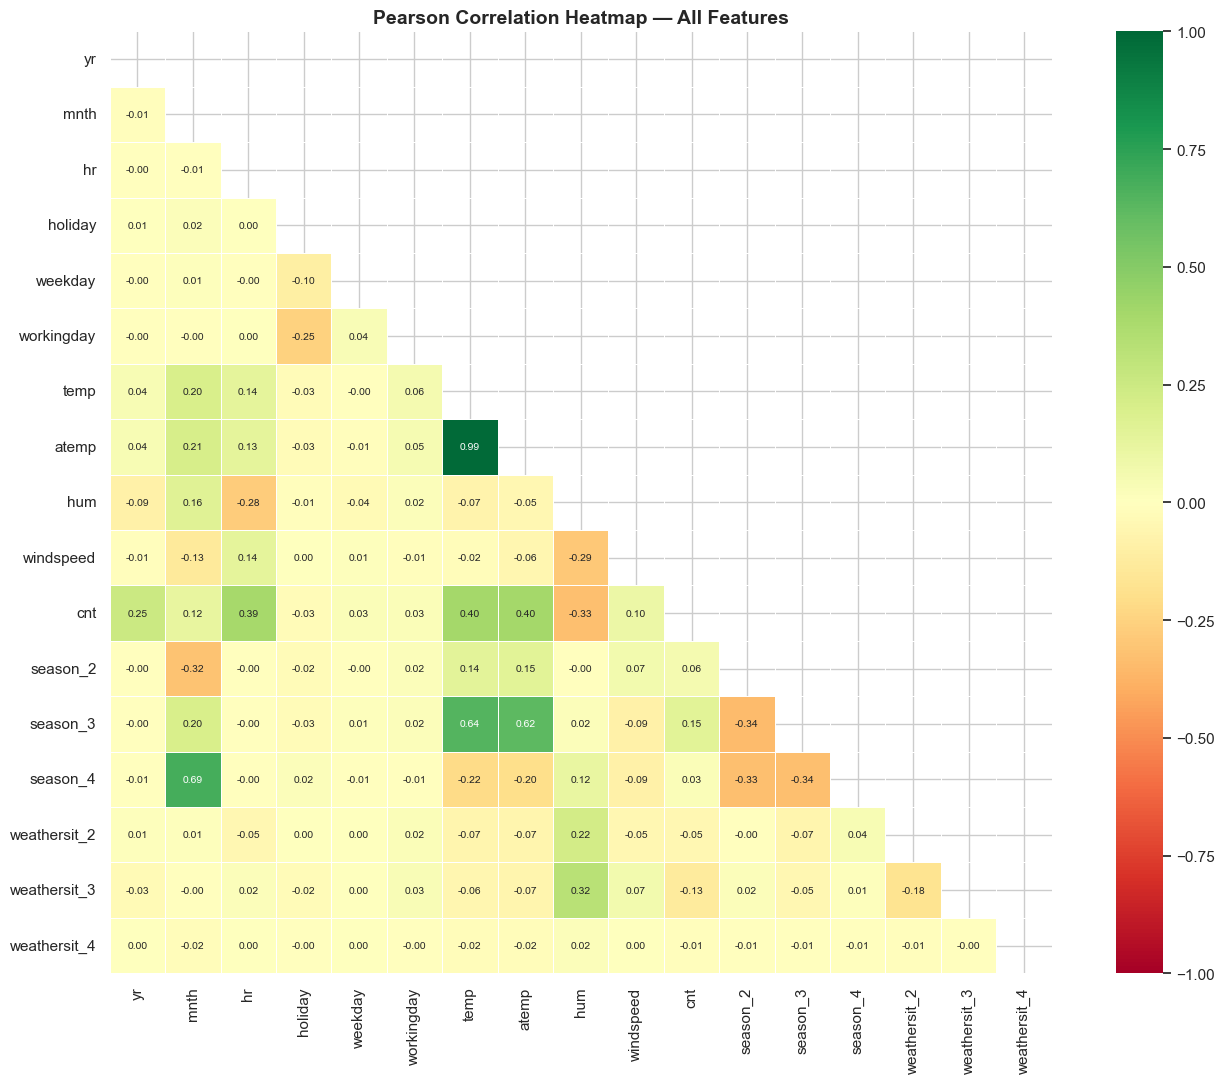

Top 10 absolute correlations with target (cnt):
  temp                : 0.4048
  atemp               : 0.4009
  hr                  : 0.3941
  hum                 : 0.3288
  yr                  : 0.2505
  season_3            : 0.1516
  weathersit_3        : 0.1280
  mnth                : 0.1206
  windspeed           : 0.0980
  season_2            : 0.0607


In [14]:
plt.figure(figsize=(14, 11))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.4,
    annot_kws={'size': 7.5}, vmin=-1, vmax=1, square=True
)
plt.title('Pearson Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 absolute correlations with target (cnt):')
cnt_corr = corr['cnt'].drop('cnt').abs().sort_values(ascending=False)
for feat, val in cnt_corr.head(10).items():
    print(f'  {feat:20s}: {val:.4f}')

### Hourly Rental Patterns

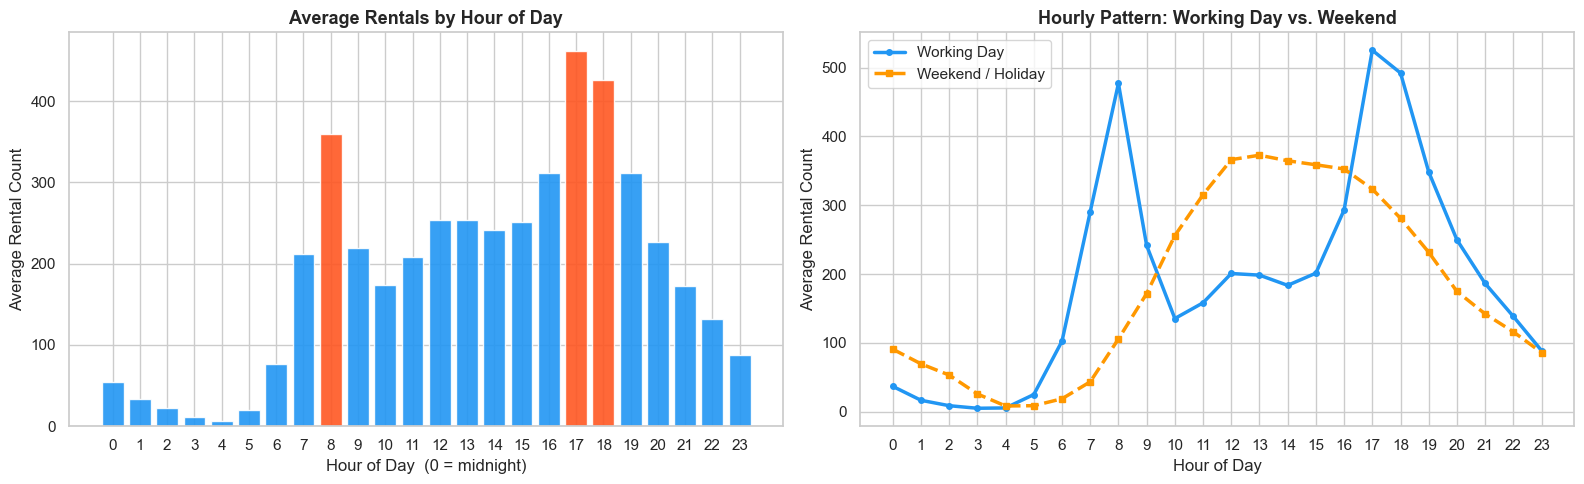

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_avg = df_eda.groupby('hr')['cnt'].mean()
bar_colors = ['#FF5722' if h in [8, 17, 18] else '#2196F3' for h in hourly_avg.index]
axes[0].bar(hourly_avg.index, hourly_avg.values, color=bar_colors, edgecolor='white', alpha=0.9)
axes[0].set_title('Average Rentals by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day  (0 = midnight)')
axes[0].set_ylabel('Average Rental Count')
axes[0].set_xticks(range(0, 24))

workday = df_eda[df_eda['workingday'] == 1].groupby('hr')['cnt'].mean()
weekend = df_eda[df_eda['workingday'] == 0].groupby('hr')['cnt'].mean()
axes[1].plot(workday.index, workday.values, 'o-', color='#2196F3', lw=2.5, ms=4, label='Working Day')
axes[1].plot(weekend.index, weekend.values, 's--', color='#FF9800', lw=2.5, ms=4, label='Weekend / Holiday')
axes[1].set_title('Hourly Pattern: Working Day vs. Weekend', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Rental Count')
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_03_hourly_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

### Seasonal & Monthly Patterns

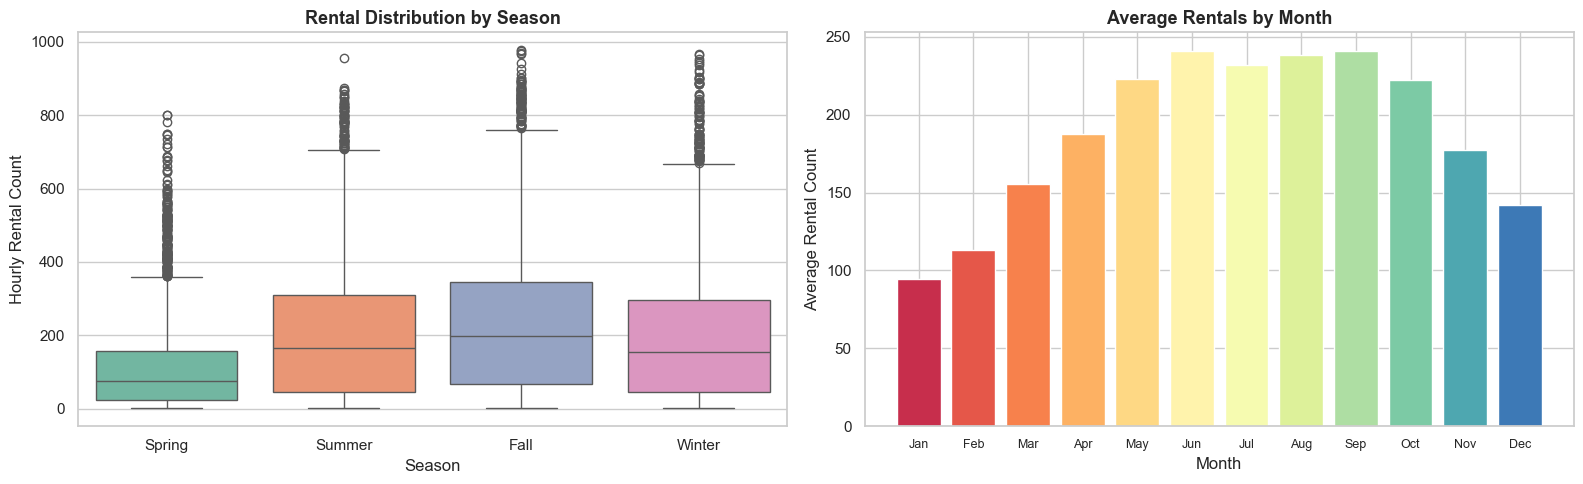

In [16]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_eda['season_name'] = df_eda['season'].map(season_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
sns.boxplot(data=df_eda, x='season_name', y='cnt',
            order=season_order, palette='Set2', ax=axes[0])
axes[0].set_title('Rental Distribution by Season', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Hourly Rental Count')

monthly_avg = df_eda.groupby('mnth')['cnt'].mean()
month_lbl   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(range(1, 13), monthly_avg.values,
            color=sns.color_palette('Spectral', 12), edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_lbl, fontsize=9)
axes[1].set_title('Average Rentals by Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Rental Count')

plt.tight_layout()
plt.savefig('eda_04_seasonal_monthly.png', dpi=120, bbox_inches='tight')
plt.show()
df_eda.drop(columns=['season_name'], inplace=True)

### Weather Impact

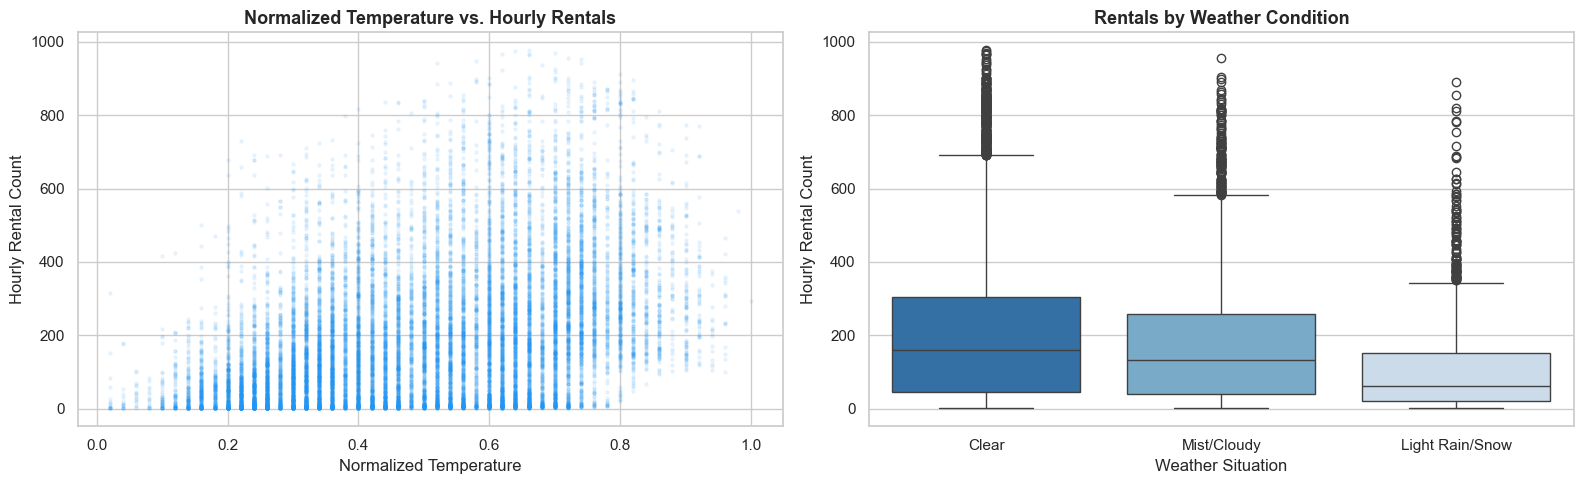

In [17]:
weather_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Ice'}
df_eda['weather_label'] = df_eda['weathersit'].map(weather_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(df_eda['temp'], df_eda['cnt'], alpha=0.08, s=5, color='#2196F3')
axes[0].set_title('Normalized Temperature vs. Hourly Rentals', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Normalized Temperature')
axes[0].set_ylabel('Hourly Rental Count')

w_order  = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow']
w_subset = df_eda[df_eda['weather_label'].isin(w_order)]
sns.boxplot(data=w_subset, x='weather_label', y='cnt',
            order=w_order, palette='Blues_r', ax=axes[1])
axes[1].set_title('Rentals by Weather Condition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weather Situation')
axes[1].set_ylabel('Hourly Rental Count')

plt.tight_layout()
plt.savefig('eda_05_weather_impact.png', dpi=120, bbox_inches='tight')
plt.show()
df_eda.drop(columns=['weather_label'], inplace=True)

## Feature Selection


### Pearson Correlation with Target

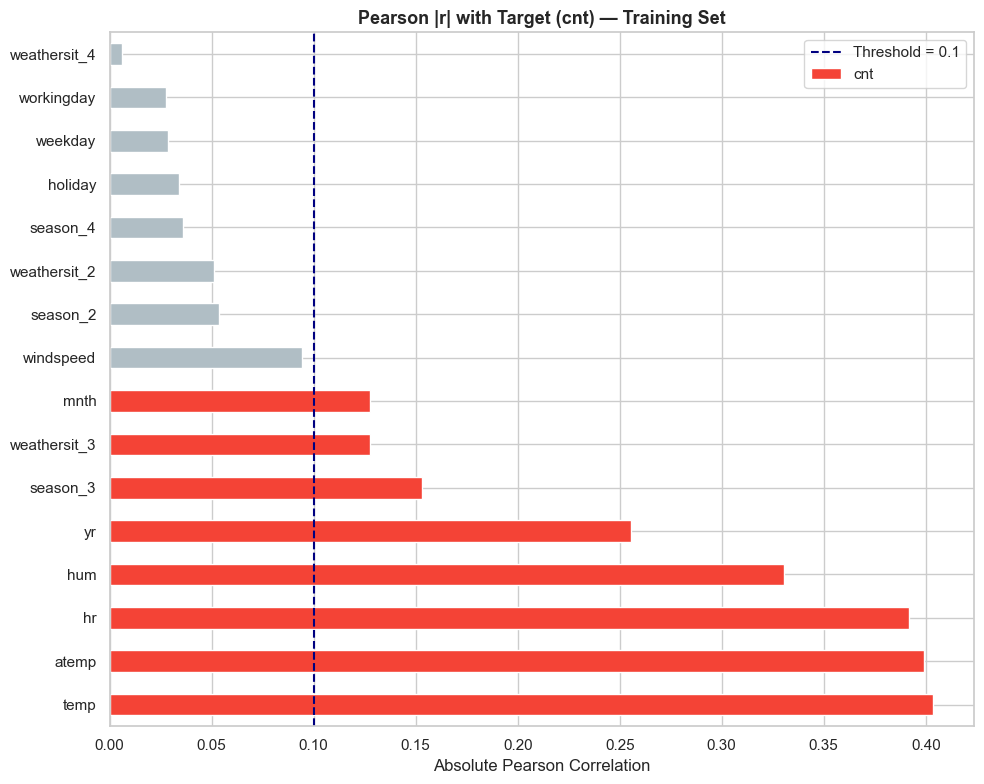

Features with |r| >= 0.1: 8
['temp', 'atemp', 'hr', 'hum', 'yr', 'season_3', 'weathersit_3', 'mnth']


In [18]:
train_df_corr = pd.DataFrame(X_train_scaled, columns=feature_names)
train_df_corr['cnt'] = y_train.values

corr_target     = train_df_corr.corr()['cnt'].drop('cnt').abs().sort_values(ascending=False)
pearson_thresh  = 0.10
pearson_sel     = corr_target[corr_target >= pearson_thresh].index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
bar_c = ['#F44336' if v >= pearson_thresh else '#B0BEC5' for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=bar_c, edgecolor='white')
ax.axvline(pearson_thresh, color='navy', linestyle='--', lw=1.5, label=f'Threshold = {pearson_thresh}')
ax.set_title('Pearson |r| with Target (cnt) — Training Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Pearson Correlation')
ax.legend()
plt.tight_layout()
plt.savefig('fs_01_pearson.png', dpi=120, bbox_inches='tight')
plt.show()

n_sel = len(pearson_sel)
print(f'Features with |r| >= {pearson_thresh}: {n_sel}')
print(pearson_sel)

### Random Forest Feature Importance

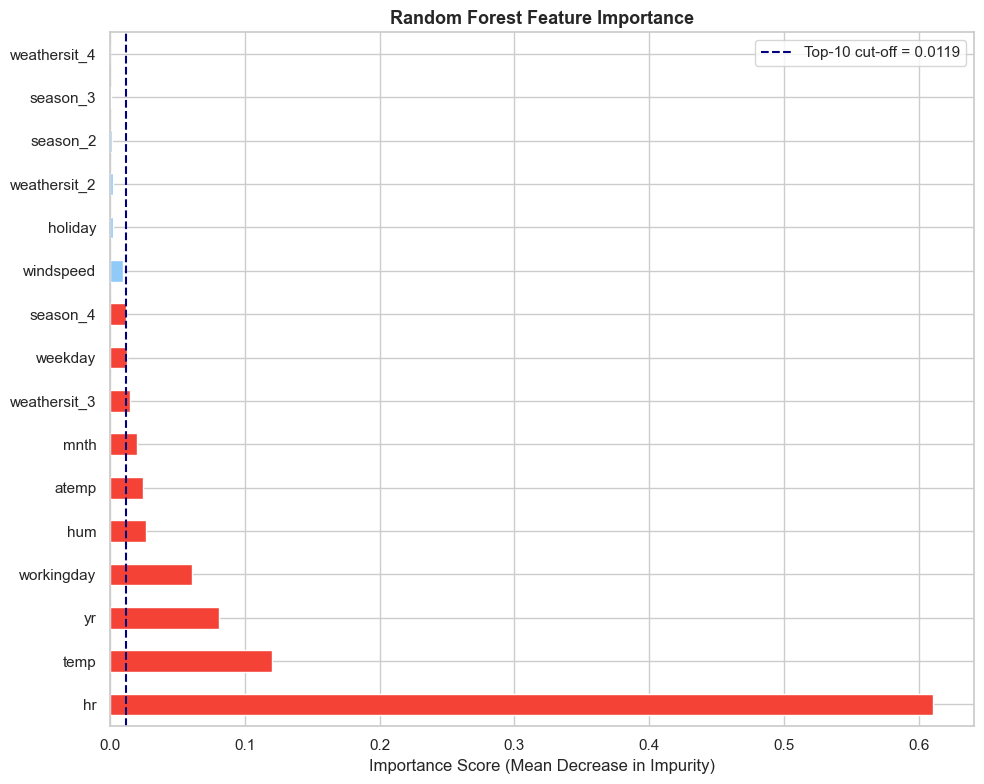

Top 10 features by RF importance:
  hr                  : 0.6102
  temp                : 0.1202
  yr                  : 0.0808
  workingday          : 0.0612
  hum                 : 0.0266
  atemp               : 0.0244
  mnth                : 0.0199
  weathersit_3        : 0.0151
  weekday             : 0.0125
  season_4            : 0.0119


In [19]:
rf_sel_model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_sel_model.fit(X_train_scaled, y_train)

importances  = pd.Series(rf_sel_model.feature_importances_, index=feature_names)
imp_sorted   = importances.sort_values(ascending=False)
top10_thresh = imp_sorted.iloc[9]

fig, ax = plt.subplots(figsize=(10, 8))
imp_c = ['#F44336' if v >= top10_thresh else '#90CAF9' for v in imp_sorted.values]
imp_sorted.plot(kind='barh', ax=ax, color=imp_c, edgecolor='white')
ax.axvline(top10_thresh, color='navy', linestyle='--', lw=1.5,
           label=f'Top-10 cut-off = {top10_thresh:.4f}')
ax.set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
ax.legend()
plt.tight_layout()
plt.savefig('fs_02_rf_importance.png', dpi=120, bbox_inches='tight')
plt.show()

rf_sel = imp_sorted.head(10).index.tolist()
print('Top 10 features by RF importance:')
for feat in rf_sel:
    score = imp_sorted[feat]
    print(f'  {feat:20s}: {score:.4f}')

### Final Feature Selection (Union Method)

In [20]:
final_features = list(dict.fromkeys(pearson_sel + rf_sel))

print('FINAL FEATURE SELECTION')
print('=' * 52)
n_p = len(pearson_sel)
n_r = len(rf_sel)
n_f = len(final_features)
print(f'  Pearson (|r| >= {pearson_thresh})  : {n_p} features')
print(f'  RF Importance (top 10) : {n_r} features')
print(f'  Union (final set)      : {n_f} features')
print(f'\n  Selected features:')
for i, f in enumerate(final_features, 1):
    print(f'    {i:2d}. {f}')

sel_idx     = [feature_names.index(f) for f in final_features]
X_train_sel = X_train_scaled[:, sel_idx]
X_test_sel  = X_test_scaled[:,  sel_idx]

print(f'\n  X_train_sel : {X_train_sel.shape}')
print(f'  X_test_sel  : {X_test_sel.shape}')

FINAL FEATURE SELECTION
  Pearson (|r| >= 0.1)  : 8 features
  RF Importance (top 10) : 10 features
  Union (final set)      : 11 features

  Selected features:
     1. temp
     2. atemp
     3. hr
     4. hum
     5. yr
     6. season_3
     7. weathersit_3
     8. mnth
     9. workingday
    10. weekday
    11. season_4

  X_train_sel : (13903, 11)
  X_test_sel  : (3476, 11)


## Model Building

In [21]:
def compute_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {
        'Model' : name,
        'MAE'   : round(mae,  3),
        'MAPE%' : round(mape, 3),
        'MSE'   : round(mse,  2),
        'RMSE'  : round(rmse, 3),
        'R2'    : round(r2,   4)
    }

def run_model(name, model, X_tr, y_tr, X_te, y_te, cv=4):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    cv_sc  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2', n_jobs=-1)
    m = compute_metrics(name, y_te, y_pred)
    m['CV_R2_Mean'] = round(cv_sc.mean(), 4)
    m['CV_R2_Std']  = round(cv_sc.std(),  4)
    mae_v  = m['MAE']
    mape_v = m['MAPE%']
    mse_v  = m['MSE']
    rmse_v = m['RMSE']
    r2_v   = m['R2']
    cv_m   = m['CV_R2_Mean']
    cv_s   = m['CV_R2_Std']
    print(f'  {"-"*52}')
    print(f'  MODEL : {name}')
    print(f'  {"-"*52}')
    print(f'  Test MAE   : {mae_v}')
    print(f'  Test MAPE  : {mape_v}%')
    print(f'  Test MSE   : {mse_v}')
    print(f'  Test RMSE  : {rmse_v}')
    print(f'  Test R2    : {r2_v}')
    print(f'  4-Fold CV R2: {cv_m} +/- {cv_s}')
    return model, y_pred, m

baseline_results = []
print('Helper functions defined.')

Helper functions defined.


### Ridge Regression

In [22]:
ridge_model, y_pred_ridge, m_ridge = run_model(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_train_sel, y_train, X_test_sel, y_test
)
baseline_results.append(m_ridge)

  ----------------------------------------------------
  MODEL : Ridge Regression
  ----------------------------------------------------
  Test MAE   : 103.838
  Test MAPE  : 346.725%
  Test MSE   : 19092.03
  Test RMSE  : 138.174
  Test R2    : 0.3971
  4-Fold CV R2: 0.3962 +/- 0.0082


### Random Forest Regressor

In [23]:
rf_model, y_pred_rf, m_rf = run_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_sel, y_train, X_test_sel, y_test
)
baseline_results.append(m_rf)

  ----------------------------------------------------
  MODEL : Random Forest
  ----------------------------------------------------
  Test MAE   : 24.806
  Test MAPE  : 32.71%
  Test MSE   : 1823.14
  Test RMSE  : 42.698
  Test R2    : 0.9424
  4-Fold CV R2: 0.9391 +/- 0.0046


### Gradient Boosting Regressor

In [24]:
gbm_model, y_pred_gbm, m_gbm = run_model(
    'Gradient Boosting',
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                               max_depth=5, random_state=42),
    X_train_sel, y_train, X_test_sel, y_test
)
baseline_results.append(m_gbm)

  ----------------------------------------------------
  MODEL : Gradient Boosting
  ----------------------------------------------------
  Test MAE   : 28.555
  Test MAPE  : 47.282%
  Test MSE   : 2038.08
  Test RMSE  : 45.145
  Test R2    : 0.9356
  4-Fold CV R2: 0.9325 +/- 0.0038


BASELINE MODEL COMPARISON
            Model     MAE   MAPE%      MSE    RMSE     R2  CV_R2_Mean  CV_R2_Std
 Ridge Regression 103.838 346.725 19092.03 138.174 0.3971      0.3962     0.0082
    Random Forest  24.806  32.710  1823.14  42.698 0.9424      0.9391     0.0046
Gradient Boosting  28.555  47.282  2038.08  45.145 0.9356      0.9325     0.0038

Best baseline model: Random Forest  (R2 = 0.9424)


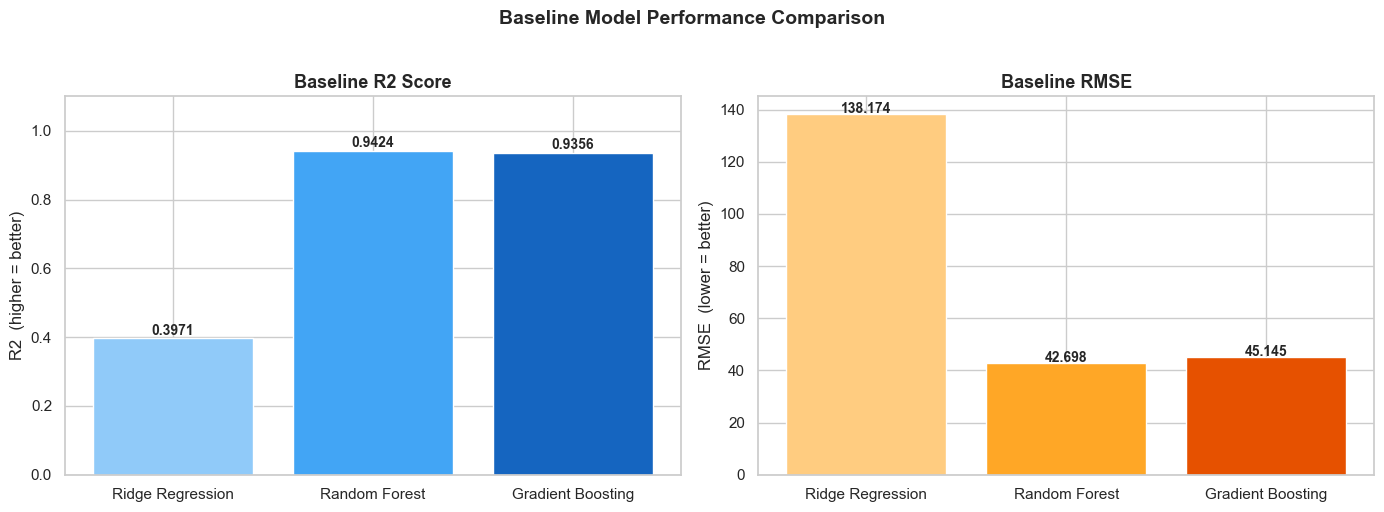

In [25]:
base_df = pd.DataFrame(baseline_results)
print('BASELINE MODEL COMPARISON')
print('=' * 75)
print(base_df[['Model','MAE','MAPE%','MSE','RMSE','R2','CV_R2_Mean','CV_R2_Std']].to_string(index=False))

best_base = base_df.loc[base_df['R2'].idxmax(), 'Model']
best_r2   = base_df['R2'].max()
print(f'\nBest baseline model: {best_base}  (R2 = {best_r2})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = [r['Model'] for r in baseline_results]
r2_vals     = [r['R2']    for r in baseline_results]
rmse_vals   = [r['RMSE']  for r in baseline_results]

axes[0].bar(model_names, r2_vals, color=['#90CAF9','#42A5F5','#1565C0'], edgecolor='white')
axes[0].set_title('Baseline R2 Score', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R2  (higher = better)')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontsize=10, fontweight='bold')

axes[1].bar(model_names, rmse_vals, color=['#FFCC80','#FFA726','#E65100'], edgecolor='white')
axes[1].set_title('Baseline RMSE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE  (lower = better)')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Baseline Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_08_baseline_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Model Optimization


### Ridge Regression — GridSearchCV (cv=4)

In [26]:
print('RIDGE REGRESSION — GridSearchCV  (cv=4)')
print('=' * 48)

param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]}

gs_ridge = GridSearchCV(
    Ridge(), param_grid_ridge,
    cv=4, scoring='r2', n_jobs=-1, refit=True
)
gs_ridge.fit(X_train_sel, y_train)

best_ridge       = gs_ridge.best_estimator_
y_pred_ridge_opt = best_ridge.predict(X_test_sel)
m_ridge_opt      = compute_metrics('Ridge (Tuned)', y_test, y_pred_ridge_opt)

bp   = gs_ridge.best_params_
bcv  = round(gs_ridge.best_score_, 4)
d_r2 = round(m_ridge_opt['R2'] - m_ridge['R2'], 4)
print(f'Best parameters : {bp}')
print(f'Best CV R2      : {bcv}')
print(f'\nBaseline R2  : {m_ridge["R2"]}  ->  Tuned R2  : {m_ridge_opt["R2"]}  (delta: {d_r2:+})')
print(f'Baseline RMSE: {m_ridge["RMSE"]}  ->  Tuned RMSE: {m_ridge_opt["RMSE"]}')

RIDGE REGRESSION — GridSearchCV  (cv=4)
Best parameters : {'alpha': 0.001}
Best CV R2      : 0.3962

Baseline R2  : 0.3971  ->  Tuned R2  : 0.3971  (delta: +0.0)
Baseline RMSE: 138.174  ->  Tuned RMSE: 138.174


### Random Forest — RandomizedSearchCV (cv=4, n_iter=40)

In [27]:
print('RANDOM FOREST — RandomizedSearchCV  (cv=4, n_iter=40)')
print('=' * 58)

param_dist_rf = {
    'n_estimators'     : [100, 150, 200, 250, 300, 400, 500],
    'max_depth'        : [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 3, 5, 7, 10],
    'min_samples_leaf' : [1, 2, 3, 4],
    'max_features'     : ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap'        : [True, False]
}

rs_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=40, cv=4,
    scoring='r2', random_state=42, n_jobs=-1, refit=True, verbose=1
)
rs_rf.fit(X_train_sel, y_train)

best_rf       = rs_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test_sel)
m_rf_opt      = compute_metrics('Random Forest (Tuned)', y_test, y_pred_rf_opt)

bp    = rs_rf.best_params_
bcv   = round(rs_rf.best_score_, 4)
d_r2  = round(m_rf_opt['R2'] - m_rf['R2'], 4)
print(f'\nBest parameters : {bp}')
print(f'Best CV R2      : {bcv}')
print(f'\nBaseline R2  : {m_rf["R2"]}  ->  Tuned R2  : {m_rf_opt["R2"]}  (delta: {d_r2:+})')
print(f'Baseline RMSE: {m_rf["RMSE"]}  ->  Tuned RMSE: {m_rf_opt["RMSE"]}')

RANDOM FOREST — RandomizedSearchCV  (cv=4, n_iter=40)
Fitting 4 folds for each of 40 candidates, totalling 160 fits

Best parameters : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_depth': 15, 'bootstrap': False}
Best CV R2      : 0.94

Baseline R2  : 0.9424  ->  Tuned R2  : 0.9429  (delta: +0.0005)
Baseline RMSE: 42.698  ->  Tuned RMSE: 42.51


### Gradient Boosting — RandomizedSearchCV (cv=4, n_iter=40)

In [28]:
print('GRADIENT BOOSTING — RandomizedSearchCV  (cv=4, n_iter=40)')
print('=' * 62)

param_dist_gbm = {
    'n_estimators'     : [100, 150, 200, 250, 300, 400],
    'learning_rate'    : [0.01, 0.05, 0.08, 0.1, 0.15, 0.2],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 3, 5, 7],
    'min_samples_leaf' : [1, 2, 3, 4],
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'max_features'     : ['sqrt', 'log2', None]
}

rs_gbm = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist_gbm, n_iter=40, cv=4,
    scoring='r2', random_state=42, n_jobs=-1, refit=True, verbose=1
)
rs_gbm.fit(X_train_sel, y_train)

best_gbm       = rs_gbm.best_estimator_
y_pred_gbm_opt = best_gbm.predict(X_test_sel)
m_gbm_opt      = compute_metrics('Gradient Boosting (Tuned)', y_test, y_pred_gbm_opt)

bp    = rs_gbm.best_params_
bcv   = round(rs_gbm.best_score_, 4)
d_r2  = round(m_gbm_opt['R2'] - m_gbm['R2'], 4)
print(f'\nBest parameters : {bp}')
print(f'Best CV R2      : {bcv}')
print(f'\nBaseline R2  : {m_gbm["R2"]}  ->  Tuned R2  : {m_gbm_opt["R2"]}  (delta: {d_r2:+})')
print(f'Baseline RMSE: {m_gbm["RMSE"]}  ->  Tuned RMSE: {m_gbm_opt["RMSE"]}')

GRADIENT BOOSTING — RandomizedSearchCV  (cv=4, n_iter=40)
Fitting 4 folds for each of 40 candidates, totalling 160 fits

Best parameters : {'subsample': 0.7, 'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 8, 'learning_rate': 0.1}
Best CV R2      : 0.9491

Baseline R2  : 0.9356  ->  Tuned R2  : 0.953  (delta: +0.0174)
Baseline RMSE: 45.145  ->  Tuned RMSE: 38.564


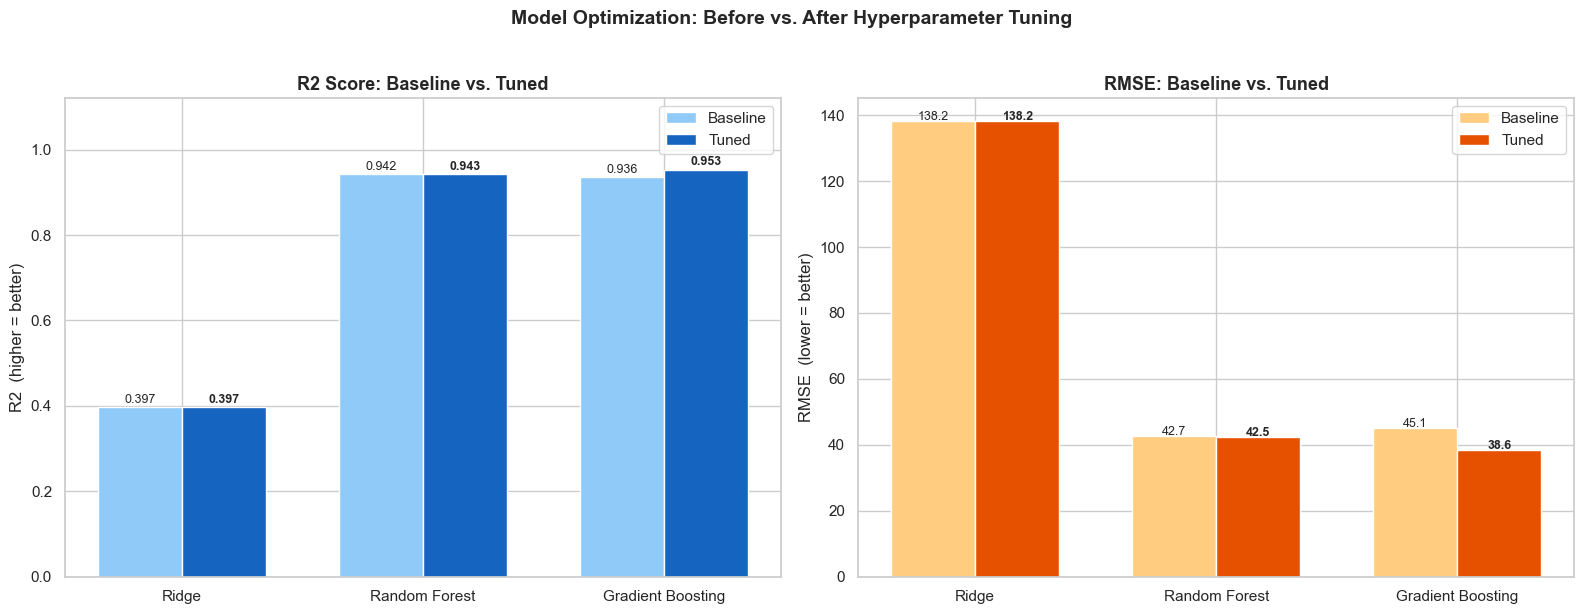

In [29]:
x = np.arange(3)
w = 0.35
labels  = ['Ridge', 'Random Forest', 'Gradient Boosting']
r2_base = [m_ridge['R2'],     m_rf['R2'],     m_gbm['R2']]
r2_tune = [m_ridge_opt['R2'], m_rf_opt['R2'], m_gbm_opt['R2']]
rm_base = [m_ridge['RMSE'],     m_rf['RMSE'],     m_gbm['RMSE']]
rm_tune = [m_ridge_opt['RMSE'], m_rf_opt['RMSE'], m_gbm_opt['RMSE']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - w/2, r2_base, w, label='Baseline', color='#90CAF9', edgecolor='white')
axes[0].bar(x + w/2, r2_tune, w, label='Tuned',    color='#1565C0', edgecolor='white')
for i, (b, t) in enumerate(zip(r2_base, r2_tune)):
    axes[0].text(i - w/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('R2 Score: Baseline vs. Tuned', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R2  (higher = better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1.12)
axes[0].legend()

axes[1].bar(x - w/2, rm_base, w, label='Baseline', color='#FFCC80', edgecolor='white')
axes[1].bar(x + w/2, rm_tune, w, label='Tuned',    color='#E65100', edgecolor='white')
for i, (b, t) in enumerate(zip(rm_base, rm_tune)):
    axes[1].text(i - w/2, b + 0.3, f'{b:.1f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, t + 0.3, f'{t:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('RMSE: Baseline vs. Tuned', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE  (lower = better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()

plt.suptitle('Model Optimization: Before vs. After Hyperparameter Tuning',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('opt_09_before_after.png', dpi=120, bbox_inches='tight')
plt.show()

## Model Evaluation & Validation

In [30]:
all_metrics = [m_ridge, m_rf, m_gbm, m_ridge_opt, m_rf_opt, m_gbm_opt]
eval_df     = pd.DataFrame(all_metrics).set_index('Model')
eval_df.drop(columns=['CV_R2_Mean', 'CV_R2_Std'], errors='ignore', inplace=True)

print('COMPLETE MODEL EVALUATION TABLE')
print('=' * 72)
print(eval_df.to_string())

best_r2_model   = eval_df['R2'].idxmax()
best_rmse_model = eval_df['RMSE'].idxmin()
best_mae_model  = eval_df['MAE'].idxmin()
print(f'\n  Best R2   : {best_r2_model}  ({eval_df["R2"].max():.4f})')
print(f'  Best RMSE : {best_rmse_model}  ({eval_df["RMSE"].min():.3f})')
print(f'  Best MAE  : {best_mae_model}  ({eval_df["MAE"].min():.3f})')

COMPLETE MODEL EVALUATION TABLE
                               MAE    MAPE%       MSE     RMSE      R2
Model                                                                 
Ridge Regression           103.838  346.725  19092.03  138.174  0.3971
Random Forest               24.806   32.710   1823.14   42.698  0.9424
Gradient Boosting           28.555   47.282   2038.08   45.145  0.9356
Ridge (Tuned)              103.839  346.727  19092.11  138.174  0.3971
Random Forest (Tuned)       25.367   33.233   1807.08   42.510  0.9429
Gradient Boosting (Tuned)   23.087   30.660   1487.17   38.564  0.9530

  Best R2   : Gradient Boosting (Tuned)  (0.9530)
  Best RMSE : Gradient Boosting (Tuned)  (38.564)
  Best MAE  : Gradient Boosting (Tuned)  (23.087)


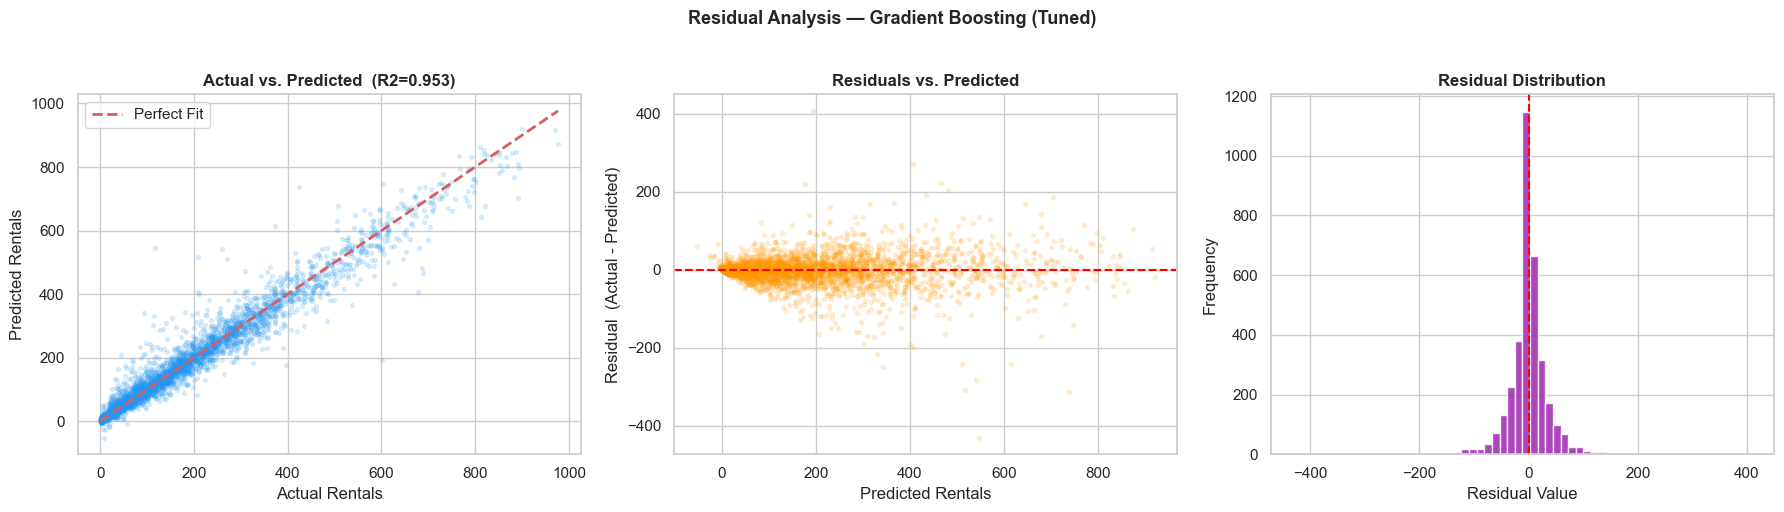

Best model: Gradient Boosting (Tuned)  |  R2 = 0.953


In [31]:
tuned_map = {
    'Ridge (Tuned)'             : y_pred_ridge_opt,
    'Random Forest (Tuned)'     : y_pred_rf_opt,
    'Gradient Boosting (Tuned)' : y_pred_gbm_opt
}
tuned_r2 = {k: r2_score(y_test, v) for k, v in tuned_map.items()}
best_name  = max(tuned_r2, key=tuned_r2.get)
best_preds = tuned_map[best_name]
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, best_preds, alpha=0.15, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Fit')
r2_best = round(r2_score(y_test, best_preds), 4)
axes[0].set_title(f'Actual vs. Predicted  (R2={r2_best})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Rentals')
axes[0].set_ylabel('Predicted Rentals')
axes[0].legend()

axes[1].scatter(best_preds, residuals, alpha=0.15, s=8, color='#FF9800')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residuals vs. Predicted', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Rentals')
axes[1].set_ylabel('Residual  (Actual - Predicted)')

axes[2].hist(residuals, bins=60, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_10_residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Best model: {best_name}  |  R2 = {r2_best}')

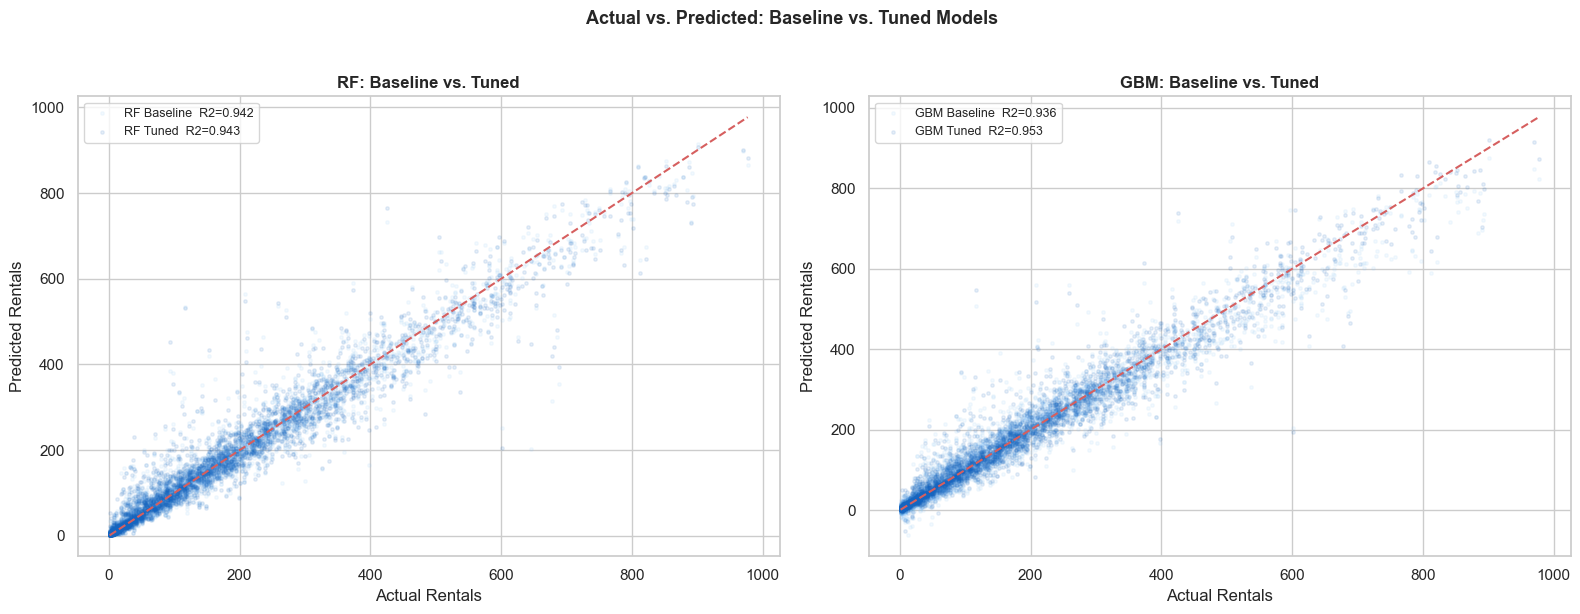

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pairs = [
    (y_pred_rf,  y_pred_rf_opt,  'RF Baseline',  'RF Tuned'),
    (y_pred_gbm, y_pred_gbm_opt, 'GBM Baseline', 'GBM Tuned'),
]
for ax, (p_b, p_t, n_b, n_t) in zip(axes, pairs):
    r2_b = round(r2_score(y_test, p_b), 3)
    r2_t = round(r2_score(y_test, p_t), 3)
    ax.scatter(y_test, p_b, alpha=0.10, s=6, color='#90CAF9', label=f'{n_b}  R2={r2_b}')
    ax.scatter(y_test, p_t, alpha=0.10, s=6, color='#1565C0', label=f'{n_t}  R2={r2_t}')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
    ax.set_xlabel('Actual Rentals')
    ax.set_ylabel('Predicted Rentals')
    ax.legend(fontsize=9)
    model_lbl = n_b.split()[0]
    ax.set_title(f'{model_lbl}: Baseline vs. Tuned', fontsize=12, fontweight='bold')

plt.suptitle('Actual vs. Predicted: Baseline vs. Tuned Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_10_baseline_vs_tuned.png', dpi=120, bbox_inches='tight')
plt.show()